<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Customer Success Analytics</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Análise da Causa Raiz da Evasão de Clientes</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Diagrama de causa e efeito PROC FISHBONE para uma revisão de retenção B2B SaaS mid-market</div>
</div>

## Resumo Executivo

Esta análise organiza os fatores de causa raiz da elevada evasão de clientes SaaS em um diagrama estruturado de causa e efeito (Ishikawa). O segmento B2B mid-market está evadindo a uma taxa de aproximadamente 18% ao ano, contra uma meta de 8%. Vinte achados de causa raiz — extraídos de pesquisas de saída, entrevistas da equipe de sucesso do cliente e atribuição por coorte — são agrupados em seis categorias de causa e renderizados com `PROC FISHBONE` como um diagrama de 27 nós (um efeito, seis espinhas de categoria, vinte subcausas).

O detalhamento de apoio do `PROC MEANS` mostra onde a evasão atribuível se concentra. **Produto** carrega o maior número de achados (5 causas, 48,1 pontos de impacto no total), seguido por **Preços** (4 causas, 42,3) e **Suporte** (4 causas, 40,2). Medido pelo impacto médio *por causa*, **Concorrência** é a categoria mais severa (média 11,8), e o achado individual de maior impacto no geral é o aumento de **Preços** na renovação sem aviso prévio (14,2). A visão de Pareto do `PROC SGPLOT` classifica cada causa individual para que a liderança veja em quais espinhas agir primeiro. O entregável alimenta a revisão trimestral de retenção do Customer Success.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.CHURN_RCA | Achados de causa raiz da evasão de clientes consolidados a partir da análise de pesquisas de saída e da retrospectiva da equipe de CS; cada linha é uma causa com sua categoria, evidência de apoio e a participação estimada na evasão | 20 |

---

In [1]:
/* --------------------------------------------------------
   Achados de causa raiz da evasão de clientes (RCA)
   Plataforma SaaS, segmento B2B mid-market.
   Cada linha: categoria da causa, a causa específica, uma
   nota de subcausa/evidência de apoio, e a participação
   estimada na evasão atribuível a ela (de pesquisas de
   saída e atribuição por coorte).
   -------------------------------------------------------- */
DADOS work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    ENTRADA category :$20. cause :$90. subcause :$110. churn_impact_pct;
    RÓTULO category="Categoria" cause="Causa" subcause="Subcausa/Evidência"
          churn_impact_pct="Impacto na Evasão (%)";
    DATALINES;
Produto|Lacunas em funcionalidades essenciais frente a concorrentes enterprise|Limites de exportação em massa e de taxa de API citados em 34% das pesquisas de saída|12.4
Produto|Capacidades de relatórios limitadas|Sem construtor de painel personalizado no nível padrão|9.8
Produto|Aplicativo móvel atrasado em relação à funcionalidade web|3 fluxos de trabalho essenciais que usuários somente-móvel não conseguem concluir|8.2
Produto|Mudanças frequentes na interface sem aviso prévio|Usuários avançados prejudicados por redesenhos trimestrais|7.6
Produto|Lacunas no marketplace de integrações|Faltam conectores nativos para Salesforce e HubSpot|10.1
Preços|Aumento no preço de renovação sem aviso prévio|Aumento de 18% na MRR com aviso de 30 dias|14.2
Preços|Modelo por usuário penaliza o crescimento da equipe|Custo dobra quando a equipe cresce de 10 para 20|11.3
Preços|Desconto inicial não renovável|Choque de preço na primeira renovação|9.7
Preços|Sem incentivo para contrato plurianual|Preço anual idêntico ao mês a mês|7.1
Suporte|Tempo de primeira resposta excede 24 horas|Referência do nível é 4 horas|10.8
Suporte|Lacuna de qualidade no suporte de fim de semana|Cobertura offshore carece de conhecimento do produto|9.3
Suporte|Sem CSM dedicado abaixo do nível Enterprise|Contas mid-market não têm contato nomeado|11.5
Suporte|Caminho de escalonamento pouco claro para os clientes|38% das contas evadidas citaram confusão sobre o escalonamento|8.6
Integração|Tempo até o valor excede 90 dias|Complexidade de implementação não divulgada antes da venda|12.9
Integração|Documentação de autoatendimento desatualizada|Última atualização há 11 meses|8.1
Integração|Sem tours guiados no aplicativo para novos recursos|Adoção de recursos abaixo de 30% em 6 meses|9.4
Concorrência|Concorrente com preço 30% menor|Três contas importantes citaram um concorrente específico|13.1
Concorrência|Concorrente oferece preço com usuários ilimitados|Elimina a penalidade por usuário para equipes em crescimento|10.6
Relacionamento|Rotatividade do patrocinador executivo sem gestão|Defensor interno saiu; sem programa de reengajamento|11.7
Relacionamento|Cadência de QBR reduzida para anual|Redução de recursos da equipe de CS há 18 meses|9.2
;
EXECUTAR;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: concentração do impacto de evasão por categoria RCA.
   A soma mostra onde a evasão atribuível se concentra; o máximo
   sinaliza a pior causa individual em cada categoria.
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.churn_rca n sum mean MAX maxdec=1;
    CLASSE category;
    VARIÁVEL churn_impact_pct;
    RÓTULO category="Categoria" churn_impact_pct="Impacto na Evasão (%)";
    TÍTULO 'Evasão de Clientes RCA: Percentual de Impacto por Categoria';
EXECUTAR;

                              Evasão de Clientes RCA: Percentual de Impacto por Categoria                               

                                                  The MEANS Procedure

                              Analysis Variable : churn_impact_pct Impacto na Evasão (%)

        Categoria               N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------------
        Concorrência                2           23.7           11.8           13.1
        Integração                  3           30.4           10.1           12.9
        Preços                      4           42.3           10.6           14.2
        Produto                     5           48.1            9.6           12.4
        Relacionamento              2           20.9           10.4           11.7
        Suporte                     4           40.2           10.1           11.5
        ---------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                              Evasão de Clientes RCA: Percentual de Impacto por Categoria                               




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


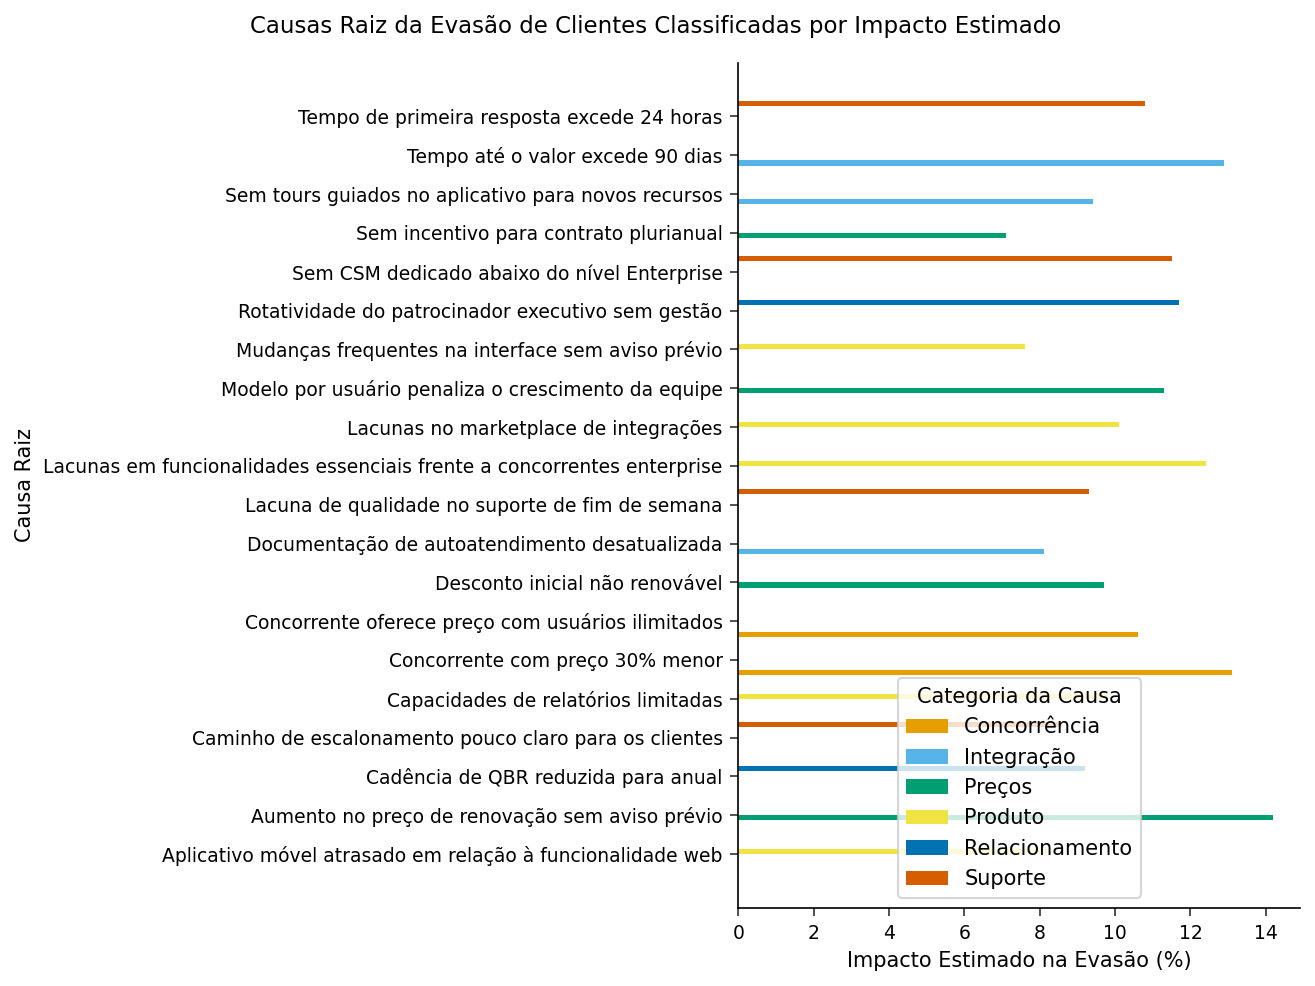

In [3]:
/* --------------------------------------------------------
   Visão de Pareto: causas raiz individuais classificadas pelo
   impacto estimado na evasão, coloridas por categoria. Isso
   complementa o fishbone quantificando quais espinhas importam mais.
   -------------------------------------------------------- */
PROCEDIMENTO ORDENAR DADOS=work.churn_rca;
    POR DECRESCENTE churn_impact_pct;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS RÓTULO='Impacto Estimado na Evasão (%)';
    YAXIS RÓTULO='Causa Raiz' discreteorder=data;
    keylegend / title='Categoria da Causa' position=bottom;
    TÍTULO 'Causas Raiz da Evasão de Clientes Classificadas por Impacto Estimado';
EXECUTAR;

---

### Diagrama de causa e efeito (Ishikawa)

O `PROC FISHBONE` constrói o diagrama diretamente a partir de `WORK.CHURN_RCA`: cada `category` distinta se torna uma espinha principal a partir do eixo central, e os achados individuais de `cause` ficam pendurados em sua espinha de categoria como subcausas. O procedimento imprime a estrutura completa de causa e efeito abaixo — o efeito na cabeça, as seis espinhas de categoria, e cada subcausa agrupada sob sua espinha — e grava o gráfico fishbone correspondente em disco. O gráfico de Pareto classificado acima é a visão complementar que quantifica quais dessas espinhas carregam a maior evasão atribuível.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: diagrama de causa e efeito da evasão de clientes.
   O diagrama é alimentado diretamente por WORK.CHURN_RCA, então
   as seis categorias de causa e suas causas são exatamente
   os achados analisados acima. CATEGORY forma as espinhas
   principais; CAUSE fica pendurada como subcausas em cada espinha.
   -------------------------------------------------------- */
PROCEDIMENTO fishbone DADOS=work.churn_rca;
    cause category / subcause=cause;
    effect 'Evasão Elevada de Clientes (18% ao ano vs. meta de 8%)';
    TÍTULO 'Análise de Causa Raiz da Evasão de Clientes - Segmento Mid-Market';
    footnote 'Fontes: pesquisas de saída, entrevistas da equipe de CS, atribuição por coorte';
EXECUTAR;

                              Evasão de Clientes RCA: Percentual de Impacto por Categoria                               


                    Análise de Causa Raiz da Evasão de Clientes - Segmento Mid-Market
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Evasão Elevada de Clientes (18% ao ano vs. meta de 8%)
    [CAUSE] Preços (top)
      [SUB] Aumento no preço de renovação sem aviso prévio
      [SUB] Modelo por usuário penaliza o crescimento da equipe
      [SUB] Desconto inicial não renovável
      [SUB] Sem incentivo para contrato plurianual
    [CAUSE] Concorrência (top)
      [SUB] Concorrente com preço 30% menor
      [SUB] Concorrente oferece preço com usuários ilimitados
    [CAUSE] Integração (top)
      [SUB] Tempo até o valor excede 90 dias
      [SUB] Sem tours guiados no aplicativo para novos recursos
      [SUB] Documentação de autoatendimento desatualizada
    [CAUSE] Produto (bottom)
      [SUB] Lacunas em funcionalidades essenciais


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretação

A estrutura de causa e efeito e os números por categoria do `PROC MEANS` apontam a liderança para um pequeno número de ações de alta alavancagem. Os dois maiores achados de causa única — o aumento de **Preços** na renovação sem aviso (14,2) e o achado de **Concorrência** de que um rival vende capacidade equivalente a um preço 30% menor (13,1) — são ambos questões comerciais, não de produto, sugerindo que a transparência de preços e o posicionamento competitivo são as alavancas mais urgentes no curto prazo. O tempo até o valor da **Integração** excedendo 90 dias (12,9) é o maior achado do lado de serviço e está diretamente ligado à definição de expectativas antes da venda.

Em volume, **Produto** domina o diagrama (5 de 20 achados, 48,1 pontos de impacto no total), mas seus achados são individualmente menores (média 9,6) do que os de **Concorrência** (média 11,8) ou **Preços** (média 10,6) — um lembrete de que uma longa lista de lacunas de produto não é automaticamente a principal prioridade. A espinha de **Relacionamento** (rotatividade do patrocinador executivo e cadência de QBR reduzida, 20,9 combinados) representa mudanças de processo que a equipe de CS pode implementar dentro do trimestre atual sem investimento em produto ou preços, oferecendo o caminho mais rápido para uma melhoria mensurável na retenção. A lista completa classificada no gráfico de Pareto permite que a equipe de liderança sequencie intervenções por impacto estimado, e não por tamanho da categoria.

---

In [5]:
/* --------------------------------------------------------
   Exportar os achados de RCA de evasão para o deck de revisão de estratégia
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>